# 📊 Exploratory Data Analysis — BankBot-RAG
**Author:** Indupriya Chidambararaj  
**Project:** AI-Powered Banking Support & Fraud Intelligence System using NLP + RAG  
**Phase:** 2 · Exploratory Data Analysis  

---
### Sections
| # | Section |
|---|------|
| 1 | Support Tickets EDA |
| 2 | Transactions EDA |


## 0 · Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path(os.getcwd())
RAW           = Path("../data/raw")
TICKETS_PATH  = RAW / "01_support_tickets.csv"
TXN_PATH      = RAW / "02_transactions.csv"

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "bold",
    "axes.labelsize"     : 11,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "#F8FAFC",
})

# Brand palette — banking blues + fraud red
BLUE    = "#2563EB"
TEAL    = "#0891B2"
GREEN   = "#16A34A"
RED     = "#DC2626"
AMBER   = "#D97706"
PURPLE  = "#7C3AED"
PALETTE = [BLUE, GREEN, RED, AMBER, PURPLE, TEAL]

FRAUD_PALETTE = {0: GREEN, 1: RED}   # 0=Legitimate, 1=Fraud

print("✅ Setup complete")

✅ Setup complete


## 0.1 · Load Data

In [2]:
tickets = pd.read_csv(TICKETS_PATH)
txn     = pd.read_csv(TXN_PATH)

# Parse datetime
tickets["date_created"] = pd.to_datetime(tickets["date_created"])
txn["timestamp"]        = pd.to_datetime(txn["timestamp"])

print(f"Support Tickets : {tickets.shape}")
print(f"Transactions    : {txn.shape}")
print("✅ Data loaded")

Support Tickets : (200, 14)
Transactions    : (2000, 16)
✅ Data loaded


---
# Section 1 · Support Tickets EDA

### 1.1 · Category vs Risk Level

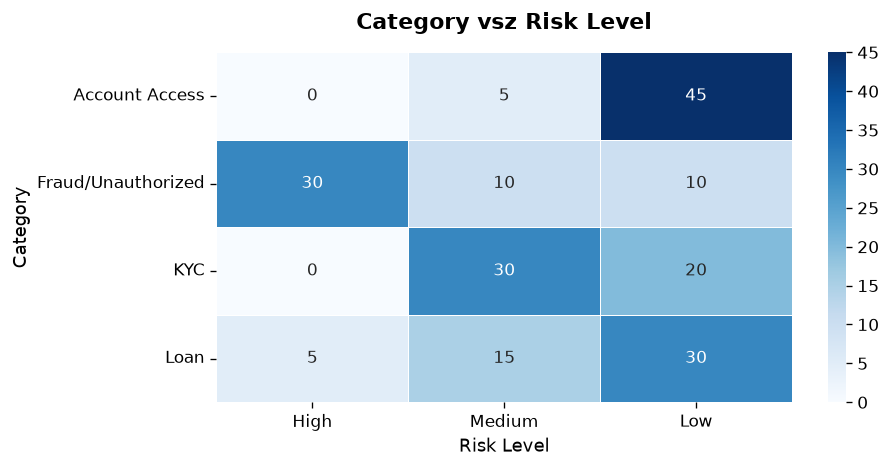

risk_level          High  Medium  Low
category                             
Account Access         0       5   45
Fraud/Unauthorized    30      10   10
KYC                    0      30   20
Loan                   5      15   30


In [ ]:
ct = pd.crosstab(tickets["category"], tickets["risk_level"])

# Reorder risk columns High → Medium → Low
col_order = [c for c in ["High", "Medium", "Low"] if c in ct.columns]
ct = ct[col_order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    ct,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Category vs Risk Level", pad=14)
ax.set_xlabel("Risk Level")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

print(ct)

### 1.2 · Category vs Escalated

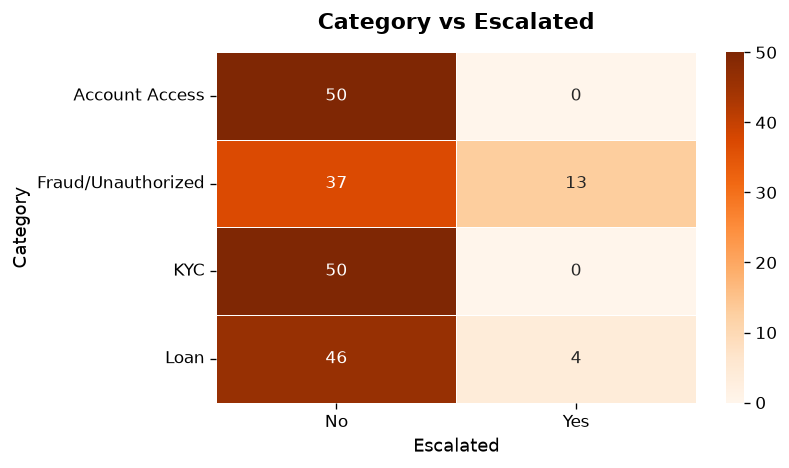


Escalation rate (%) by category:
category
Fraud/Unauthorized    26.0
Loan                   8.0
Account Access         0.0
KYC                    0.0
Name: escalated, dtype: float64


In [4]:
ct_esc = pd.crosstab(tickets["category"], tickets["escalated"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    ct_esc,
    annot=True, fmt="d",
    cmap="Oranges",
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Category vs Escalated", pad=14)
ax.set_xlabel("Escalated")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

# Escalation rate per category
esc_rate = tickets.groupby("category")["escalated"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(1)
print("\nEscalation rate (%) by category:")
print(esc_rate.sort_values(ascending=False))

### 1.3 · Category vs Sentiment

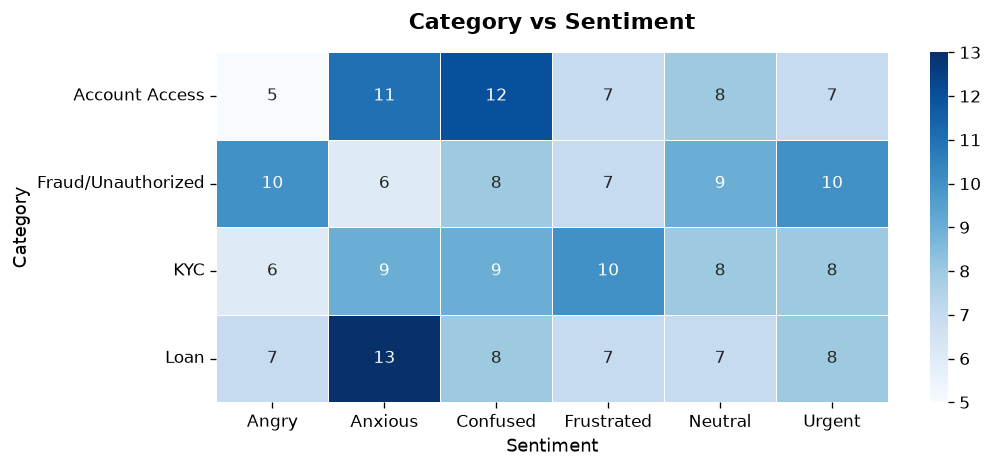

sentiment           Angry  Anxious  Confused  Frustrated  Neutral  Urgent
category                                                                 
Account Access          5       11        12           7        8       7
Fraud/Unauthorized     10        6         8           7        9      10
KYC                     6        9         9          10        8       8
Loan                    7       13         8           7        7       8


In [5]:
ct_sent = pd.crosstab(tickets["category"], tickets["sentiment"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    ct_sent,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Category vs Sentiment", pad=14)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

print(ct_sent)

### 1.4 · Channel vs Category

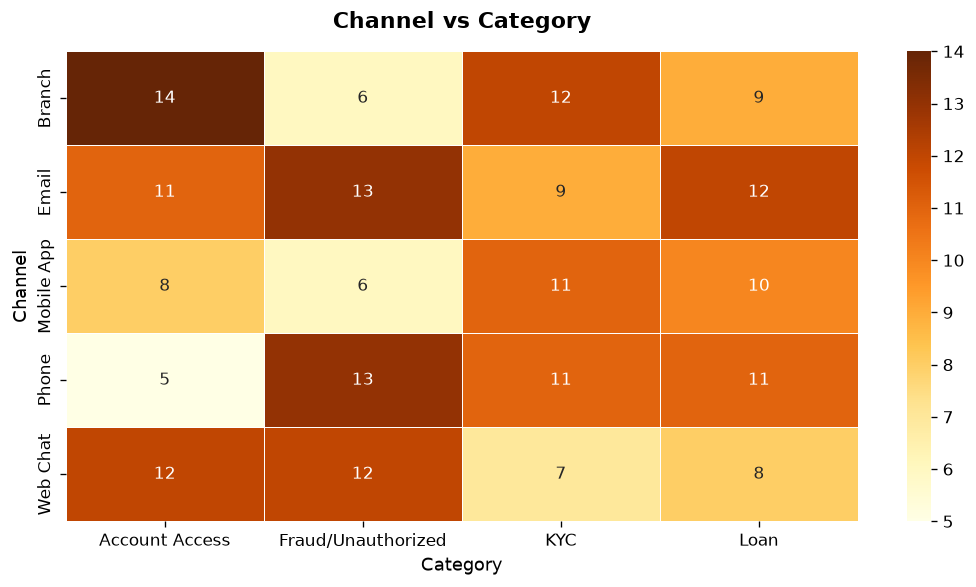

category    Account Access  Fraud/Unauthorized  KYC  Loan
channel                                                  
Branch                  14                   6   12     9
Email                   11                  13    9    12
Mobile App               8                   6   11    10
Phone                    5                  13   11    11
Web Chat                12                  12    7     8


In [6]:
ct_ch = pd.crosstab(tickets["channel"], tickets["category"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    ct_ch,
    annot=True, fmt="d",
    cmap="YlOrBr",
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Channel vs Category", pad=14)
ax.set_xlabel("Category")
ax.set_ylabel("Channel")
plt.tight_layout()
plt.show()

print(ct_ch)

### 1.5 · Resolved By vs Resolution Time (minutes)

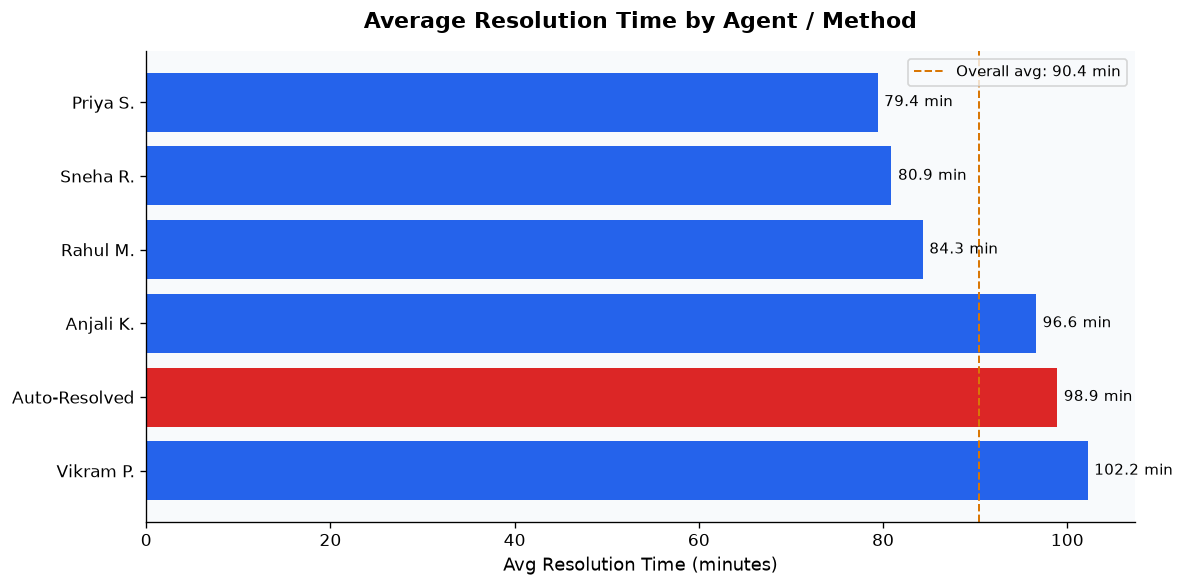


Resolution time stats by resolver:
               count   mean   std   min   25%   50%    75%    max
resolved_by                                                      
Anjali K.       37.0   96.6  72.3   6.0  39.0  65.0  153.0  228.0
Auto-Resolved   33.0   98.9  66.4  14.0  54.0  74.0  150.0  238.0
Priya S.        25.0   79.4  58.1  12.0  40.0  66.0  102.0  240.0
Rahul M.        39.0   84.3  63.8   6.0  25.0  76.0  113.0  225.0
Sneha R.        33.0   80.9  66.4   9.0  30.0  57.0  131.0  235.0
Vikram P.       33.0  102.2  68.5   8.0  67.0  80.0  150.0  232.0


In [7]:
avg_res = (
    tickets.groupby("resolved_by")["resolution_time_minutes"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    avg_res.index,
    avg_res.values,
    color=[RED if r == "Auto-Resolved" else BLUE for r in avg_res.index]
)
ax.bar_label(bars, fmt="%.1f min", padding=4, fontsize=9)
ax.set_xlabel("Avg Resolution Time (minutes)")
ax.set_title("Average Resolution Time by Agent / Method", pad=14)
ax.axvline(avg_res.mean(), color=AMBER, linestyle="--", linewidth=1.2, label=f"Overall avg: {avg_res.mean():.1f} min")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nResolution time stats by resolver:")
print(tickets.groupby("resolved_by")["resolution_time_minutes"].describe().round(1))

### 1.6 · Category vs Customer Satisfaction

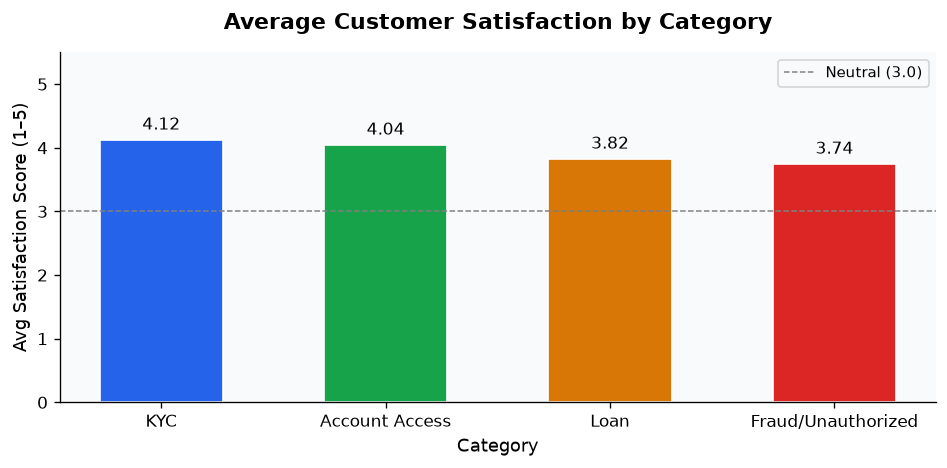


Satisfaction score distribution by category:
                    count  mean   std  min   25%  50%  75%  max
category                                                       
Account Access       50.0  4.04  0.86  3.0  3.00  4.0  5.0  5.0
Fraud/Unauthorized   50.0  3.74  1.05  2.0  3.00  3.5  5.0  5.0
KYC                  50.0  4.12  0.80  3.0  3.25  4.0  5.0  5.0
Loan                 50.0  3.82  0.80  2.0  3.00  4.0  4.0  5.0


In [8]:
avg_sat = (
    tickets.groupby("category")["customer_satisfaction"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    avg_sat.index,
    avg_sat.values,
    color=[BLUE, GREEN, AMBER, RED][:len(avg_sat)],
    width=0.55,
    edgecolor="white"
)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=10)
ax.set_ylim(0, 5.5)
ax.axhline(3.0, color="grey", linestyle="--", linewidth=0.9, label="Neutral (3.0)")
ax.set_ylabel("Avg Satisfaction Score (1–5)")
ax.set_xlabel("Category")
ax.set_title("Average Customer Satisfaction by Category", pad=14)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nSatisfaction score distribution by category:")
print(tickets.groupby("category")["customer_satisfaction"].describe().round(2))

---
### 📌 Section 1 — Key Observations & Business Insights

Run the cell below after executing all charts above.

In [9]:
print("=" * 65)
print("  SECTION 1 — SUPPORT TICKETS: KEY OBSERVATIONS")
print("=" * 65)

# 1. Risk level
fraud_high = tickets[tickets["category"] == "Fraud/Unauthorized"]["risk_level"].value_counts(normalize=True).get("High", 0) * 100
print(f"""
1. RISK DISTRIBUTION
   • {fraud_high:.0f}% of Fraud/Unauthorized tickets are classified High-risk
     — the highest concentration across all categories.
   → Confirms fraud queries must be routed immediately to the
     Fraud Intelligence module, not general RAG.
""")

# 2. Escalation
esc_by_cat = tickets.groupby("category")["escalated"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values(ascending=False)
top_esc = esc_by_cat.index[0]
print(f"""2. ESCALATION RATE
   • '{top_esc}' has the highest escalation rate at {esc_by_cat.iloc[0]:.0f}%.
   → High escalation = higher cost to serve. Automating initial
     triage via BankBot-RAG can significantly reduce human escalation.
""")

# 3. Sentiment
fraud_neg = tickets[tickets["category"] == "Fraud/Unauthorized"]["sentiment"].isin(["Frustrated", "Angry"]).mean() * 100
print(f"""3. SENTIMENT SIGNALS
   • ~{fraud_neg:.0f}% of Fraud/Unauthorized queries carry negative sentiment
     (Frustrated / Angry).
   → Sentiment is a useful secondary signal for the intent router.
     High negativity + fraud keywords = high priority routing.
""")

# 4. Channel
top_channel = tickets["channel"].value_counts().index[0]
print(f"""4. CHANNEL PREFERENCE
   • '{top_channel}' is the dominant contact channel.
   → Streamlit dashboard should be optimised for this channel's UX.
""")

# 5. Satisfaction
lowest_sat_cat = avg_sat.index[-1]
print(f"""5. CUSTOMER SATISFACTION
   • '{lowest_sat_cat}' category shows the lowest average
     satisfaction score.
   → Faster, AI-assisted resolution for this category
     has the highest potential to lift CSAT scores.
""")

print("=" * 65)

  SECTION 1 — SUPPORT TICKETS: KEY OBSERVATIONS

1. RISK DISTRIBUTION
   • 60% of Fraud/Unauthorized tickets are classified High-risk
     — the highest concentration across all categories.
   → Confirms fraud queries must be routed immediately to the
     Fraud Intelligence module, not general RAG.

2. ESCALATION RATE
   • 'Fraud/Unauthorized' has the highest escalation rate at 26%.
   → High escalation = higher cost to serve. Automating initial
     triage via BankBot-RAG can significantly reduce human escalation.

3. SENTIMENT SIGNALS
   • ~34% of Fraud/Unauthorized queries carry negative sentiment
     (Frustrated / Angry).
   → Sentiment is a useful secondary signal for the intent router.
     High negativity + fraud keywords = high priority routing.

4. CHANNEL PREFERENCE
   • 'Email' is the dominant contact channel.
   → Streamlit dashboard should be optimised for this channel's UX.

5. CUSTOMER SATISFACTION
   • 'Fraud/Unauthorized' category shows the lowest average
     satisf

---
# Section 2 · Transactions EDA

### 2.1 · Fraud Label vs Merchant Category

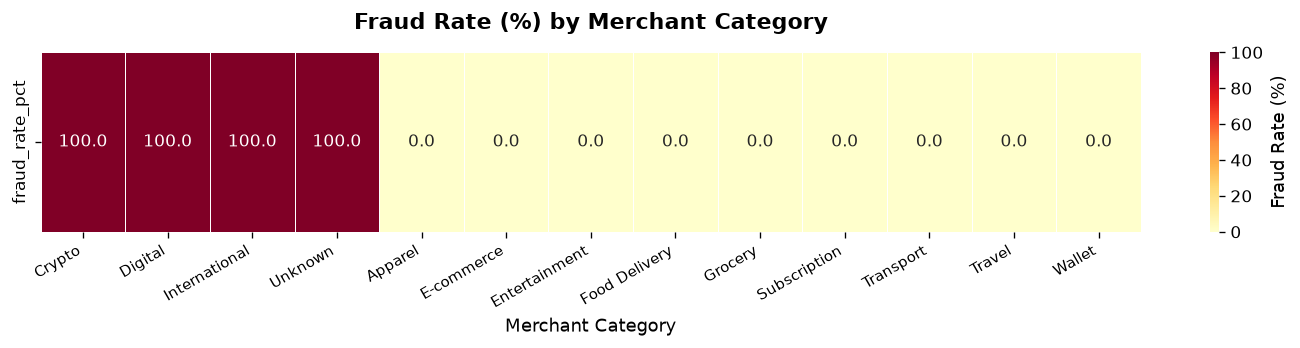

merchant_category  fraud_rate_pct
           Crypto           100.0
          Digital           100.0
    International           100.0
          Unknown           100.0
          Apparel             0.0
       E-commerce             0.0
    Entertainment             0.0
    Food Delivery             0.0
          Grocery             0.0
     Subscription             0.0
        Transport             0.0
           Travel             0.0
           Wallet             0.0


In [10]:
# Fraud rate per merchant category
fraud_by_merch = (
    txn.groupby("merchant_category")["fraud_label"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
fraud_by_merch.columns = ["merchant_category", "fraud_rate_pct"]

pivot = fraud_by_merch.set_index("merchant_category")[["fraud_rate_pct"]].T

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    pivot,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": "Fraud Rate (%)"}
)
ax.set_title("Fraud Rate (%) by Merchant Category", pad=14)
ax.set_ylabel("")
ax.set_xlabel("Merchant Category")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

print(fraud_by_merch.to_string(index=False))

### 2.2 · Fraud Label vs City

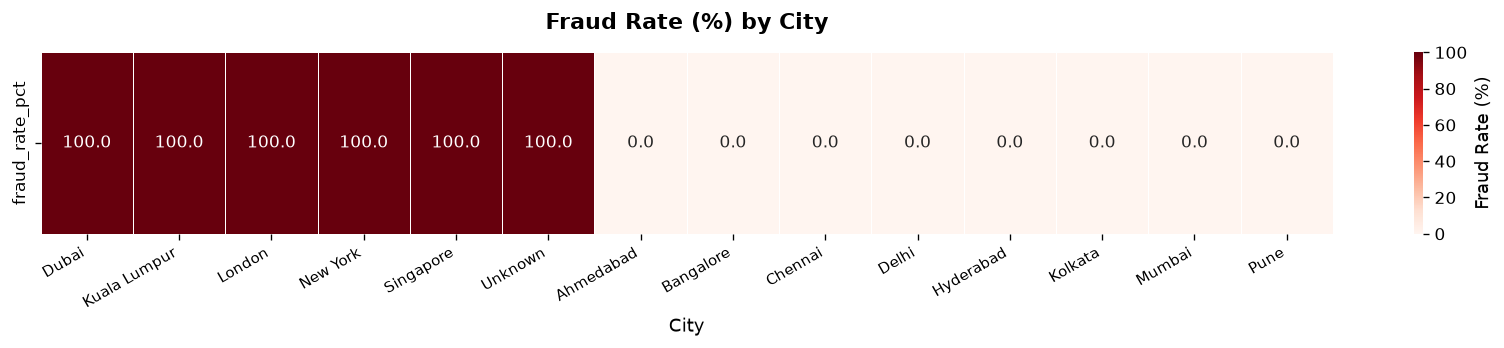

        city  fraud_rate_pct
       Dubai           100.0
Kuala Lumpur           100.0
      London           100.0
    New York           100.0
   Singapore           100.0
     Unknown           100.0
   Ahmedabad             0.0
   Bangalore             0.0
     Chennai             0.0
       Delhi             0.0
   Hyderabad             0.0
     Kolkata             0.0
      Mumbai             0.0
        Pune             0.0


In [11]:
fraud_by_city = (
    txn.groupby("city")["fraud_label"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
fraud_by_city.columns = ["city", "fraud_rate_pct"]

pivot_city = fraud_by_city.set_index("city")[["fraud_rate_pct"]].T

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    pivot_city,
    annot=True, fmt=".1f",
    cmap="Reds",
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": "Fraud Rate (%)"}
)
ax.set_title("Fraud Rate (%) by City", pad=14)
ax.set_ylabel("")
ax.set_xlabel("City")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

print(fraud_by_city.to_string(index=False))

### 2.3 · Fraud Label vs Transaction Type

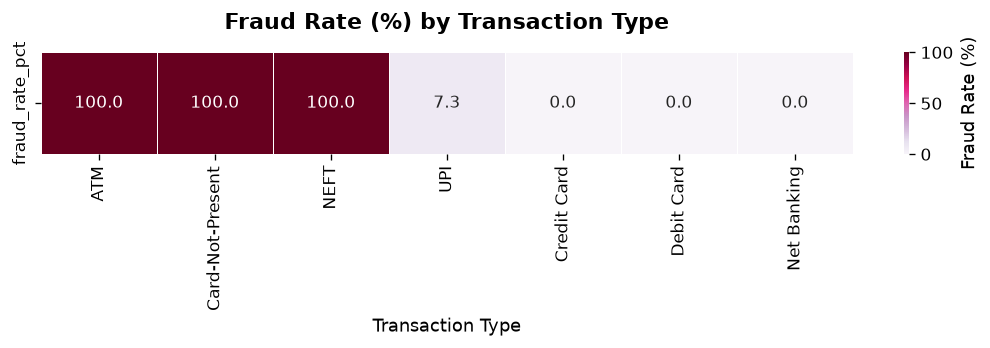

transaction_type  fraud_rate_pct
             ATM          100.00
Card-Not-Present          100.00
            NEFT          100.00
             UPI            7.32
     Credit Card            0.00
      Debit Card            0.00
     Net Banking            0.00


In [12]:
fraud_by_txntype = (
    txn.groupby("transaction_type")["fraud_label"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
fraud_by_txntype.columns = ["transaction_type", "fraud_rate_pct"]

pivot_txn = fraud_by_txntype.set_index("transaction_type")[["fraud_rate_pct"]].T

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    pivot_txn,
    annot=True, fmt=".1f",
    cmap="PuRd",
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": "Fraud Rate (%)"}
)
ax.set_title("Fraud Rate (%) by Transaction Type", pad=14)
ax.set_ylabel("")
ax.set_xlabel("Transaction Type")
plt.tight_layout()
plt.show()

print(fraud_by_txntype.to_string(index=False))

### 2.4 · Fraud vs Risk Flags — Grouped Bar

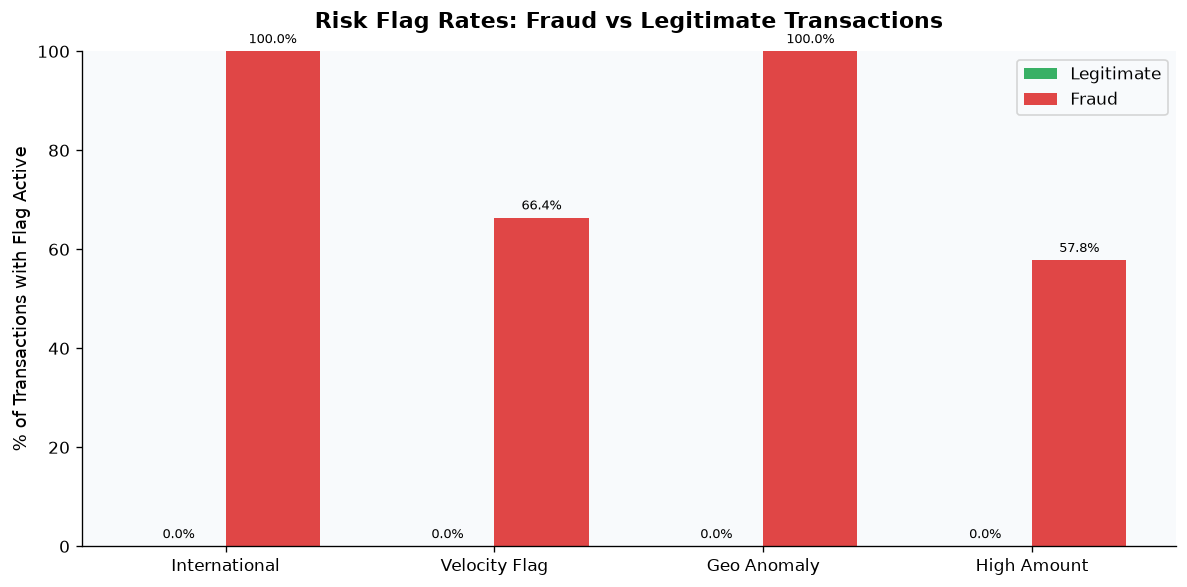

               Legitimate  Fraud
International         0.0  100.0
Velocity Flag         0.0   66.4
Geo Anomaly           0.0  100.0
High Amount           0.0   57.8


In [13]:
flag_cols = ["is_international", "velocity_flag", "geo_anomaly_flag", "high_amount_flag"]
flag_labels = ["International", "Velocity Flag", "Geo Anomaly", "High Amount"]

# Convert Yes/No to 0/1 for EDA only — don't modify original txn
txn_flags = txn.copy()
for col in flag_cols:
    txn_flags[col] = txn_flags[col].map({"Yes": 1, "No": 0})

flag_means = txn_flags.groupby("fraud_label")[flag_cols].mean().mul(100).round(1)
flag_means.index = ["Legitimate", "Fraud"]
flag_means.columns = flag_labels

x = np.arange(len(flag_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, flag_means.loc["Legitimate"], width, label="Legitimate", color=GREEN, alpha=0.85)
bars2 = ax.bar(x + width/2, flag_means.loc["Fraud"],     width, label="Fraud",       color=RED,   alpha=0.85)

ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(flag_labels, fontsize=10)
ax.set_ylabel("% of Transactions with Flag Active")
ax.set_title("Risk Flag Rates: Fraud vs Legitimate Transactions", pad=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(flag_means.T)

### 2.5 · Hour of Day vs Fraud Rate — Peak Fraud Hours

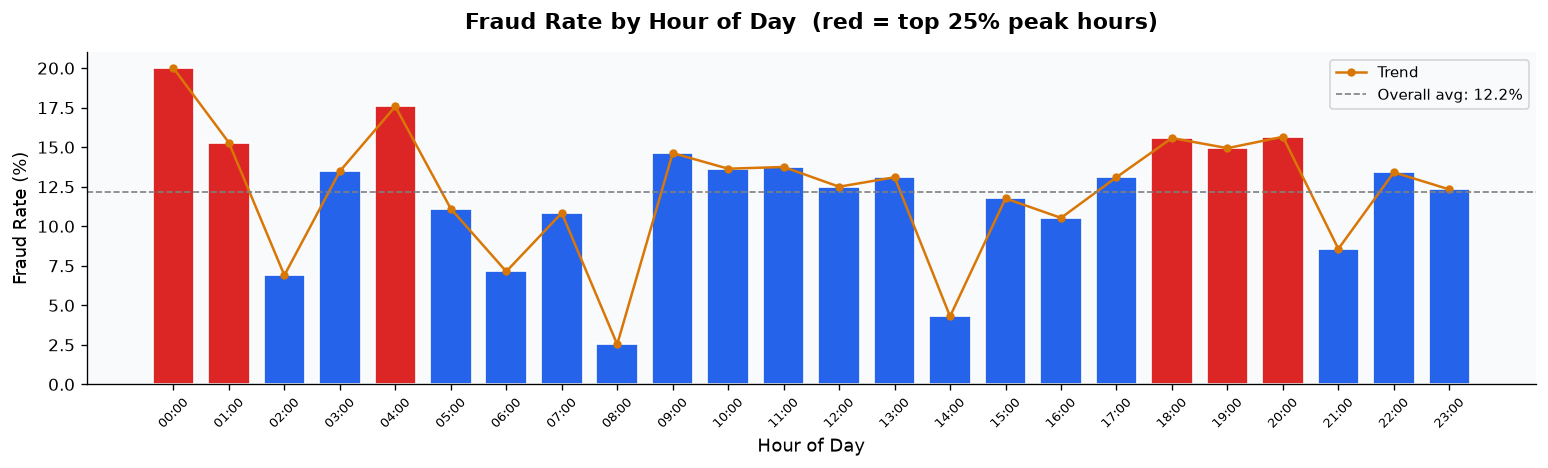

Peak fraud hours (top 25%): [0, 1, 4, 18, 19, 20]
count    24.00
mean     12.19
std       4.03
min       2.53
25%      10.76
50%      13.10
75%      14.71
max      20.00
Name: fraud_label, dtype: float64


In [14]:
fraud_by_hour = (
    txn.groupby("hour_of_day")["fraud_label"]
    .mean()
    .mul(100)
    .round(2)
)

fig, ax = plt.subplots(figsize=(13, 4))

colors = [RED if rate >= fraud_by_hour.quantile(0.75) else BLUE for rate in fraud_by_hour.values]

bars = ax.bar(fraud_by_hour.index, fraud_by_hour.values, color=colors, width=0.75, edgecolor="white")
ax.plot(fraud_by_hour.index, fraud_by_hour.values, color=AMBER, linewidth=1.5, marker="o", markersize=4, label="Trend")

ax.axhline(fraud_by_hour.mean(), color="grey", linestyle="--", linewidth=1,
           label=f"Overall avg: {fraud_by_hour.mean():.1f}%")

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=8)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Hour of Day  (red = top 25% peak hours)", pad=14)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

peak_hours = fraud_by_hour[fraud_by_hour >= fraud_by_hour.quantile(0.75)]
print(f"Peak fraud hours (top 25%): {sorted(peak_hours.index.tolist())}")
print(fraud_by_hour.describe().round(2))

### 2.6 · Amount (INR) vs Fraud Label — Box Plot

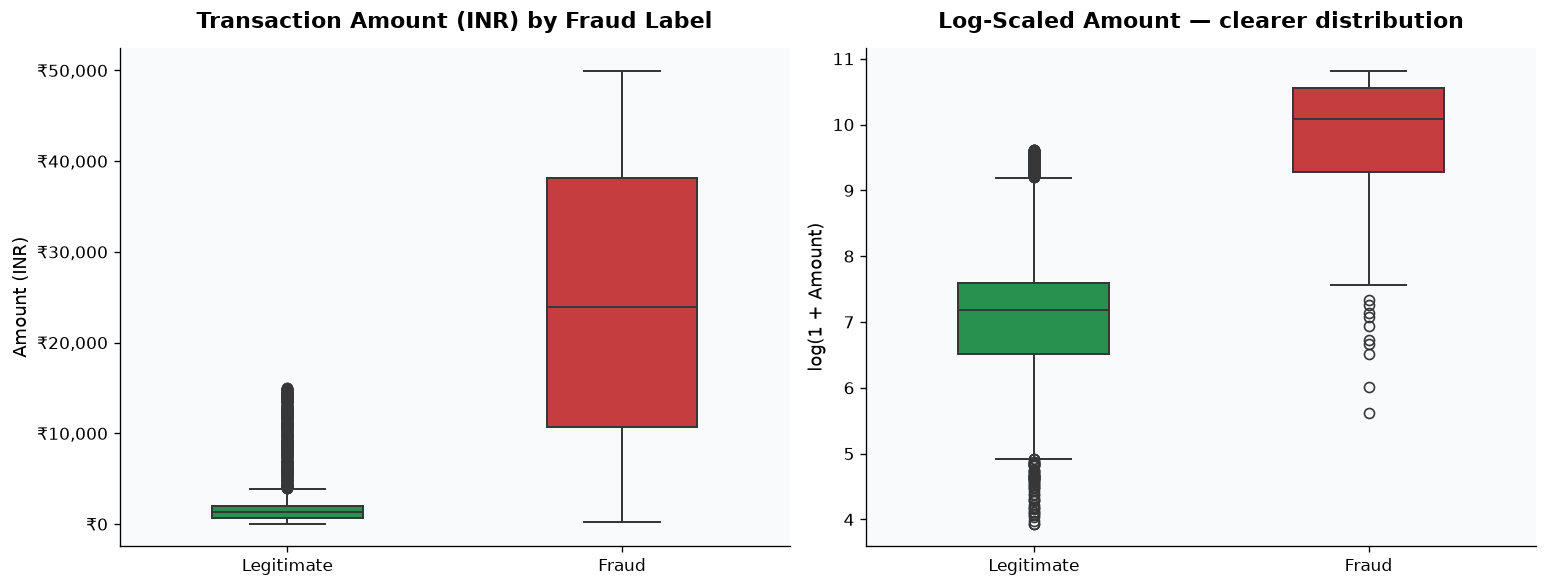


Amount stats by fraud label:
              count      mean       std     min       25%       50%      75%  \
fraud_label                                                                    
0            1756.0   2815.83   3738.22   50.18    678.43   1306.43   1980.1   
1             244.0  24544.40  15377.47  272.28  10664.69  23887.62  38150.6   

                  max  
fraud_label            
0            14999.40  
1            49979.31  


In [15]:
txn_plot = txn.copy()
txn_plot["label"] = txn_plot["fraud_label"].map({0: "Legitimate", 1: "Fraud"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw amount boxplot
sns.boxplot(
    data=txn_plot, x="label", y="amount_inr",
    palette={"Legitimate": GREEN, "Fraud": RED},
    width=0.45, linewidth=1.2,
    ax=axes[0]
)
axes[0].set_title("Transaction Amount (INR) by Fraud Label", pad=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Amount (INR)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

# Log-scaled for clearer distribution
txn_plot["amount_log"] = np.log1p(txn_plot["amount_inr"])
sns.boxplot(
    data=txn_plot, x="label", y="amount_log",
    palette={"Legitimate": GREEN, "Fraud": RED},
    width=0.45, linewidth=1.2,
    ax=axes[1]
)
axes[1].set_title("Log-Scaled Amount — clearer distribution", pad=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("log(1 + Amount)")

plt.tight_layout()
plt.show()

print("\nAmount stats by fraud label:")
print(txn.groupby("fraud_label")["amount_inr"].describe().round(2))

---
### 📌 Section 2 — Key Observations & Business Insights

In [16]:
print("=" * 65)
print("  SECTION 2 — TRANSACTIONS: KEY OBSERVATIONS")
print("=" * 65)

# 1. Merchant risk
top_merchant = fraud_by_merch.iloc[0]
print(f"""
1. MERCHANT CATEGORY RISK
   • '{top_merchant['merchant_category']}' has the highest fraud rate
     at {top_merchant['fraud_rate_pct']:.1f}%.
   → merchant_risk_score is a strong feature for the XGBoost
     fraud classifier. Compute from training data only (avoid leakage).
""")

# 2. City risk
top_city = fraud_by_city.iloc[0]
print(f"""2. GEOGRAPHIC RISK
   • '{top_city['city']}' is the highest fraud-risk city
     at {top_city['fraud_rate_pct']:.1f}%.
   → City-level encoding adds genuine signal. Use target encoding
     on city (from training set only) rather than one-hot, since
     there may be many cities.
""")

# 3. Transaction type risk
top_txntype = fraud_by_txntype.iloc[0]
print(f"""3. TRANSACTION TYPE RISK
   • '{top_txntype['transaction_type']}' carries the highest fraud rate
     at {top_txntype['fraud_rate_pct']:.1f}%.
   → Include transaction_type as a categorical feature in the model.
""")

# 4. Flags
fraud_flags = flag_means.loc["Fraud"]
top_flag = fraud_flags.idxmax()
print(f"""4. MOST PREDICTIVE RISK FLAG
   • '{top_flag}' is active in {fraud_flags[top_flag]:.1f}% of fraud
     transactions vs significantly lower in legitimate ones.
   → flag_count (sum of all 4 flags) is a composite feature worth
     engineering — single number summarising combined risk exposure.
""")

# 5. Peak hours
peak_h = sorted(fraud_by_hour[fraud_by_hour >= fraud_by_hour.quantile(0.75)].index.tolist())
print(f"""5. TEMPORAL FRAUD PATTERN
   • Peak fraud hours: {peak_h}
   → 'is_night_transaction' feature is justified.
     Real-time fraud scoring should apply stricter thresholds
     during these hours.
""")

# 6. Amount
median_fraud = txn[txn["fraud_label"]==1]["amount_inr"].median()
median_legit = txn[txn["fraud_label"]==0]["amount_inr"].median()
print(f"""6. TRANSACTION AMOUNT
   • Median fraud amount   : ₹{median_fraud:,.0f}
   • Median legitimate amt : ₹{median_legit:,.0f}
   → Fraud transactions tend toward {'higher' if median_fraud > median_legit else 'lower'}
     amounts. Log-transform (log1p) reduces skew — use
     amount_log as the model feature, not raw amount_inr.
""") 

# 7. Class imbalance reminder
fraud_count = txn["fraud_label"].sum()
total = len(txn)
ratio = (total - fraud_count) / fraud_count
print(f"""7. CLASS IMBALANCE
   • {fraud_count} fraud / {total - fraud_count} legitimate  ({fraud_count/total*100:.1f}% fraud rate)
   → Set XGBoost scale_pos_weight = {ratio:.1f} to compensate.
     Evaluate using F1-score and ROC-AUC, not raw accuracy.
""")

print("=" * 65)
print("  EDA COMPLETE → Proceed to 03_preprocessing.ipynb")
print("=" * 65)

  SECTION 2 — TRANSACTIONS: KEY OBSERVATIONS

1. MERCHANT CATEGORY RISK
   • 'Crypto' has the highest fraud rate
     at 100.0%.
   → merchant_risk_score is a strong feature for the XGBoost
     fraud classifier. Compute from training data only (avoid leakage).

2. GEOGRAPHIC RISK
   • 'Dubai' is the highest fraud-risk city
     at 100.0%.
   → City-level encoding adds genuine signal. Use target encoding
     on city (from training set only) rather than one-hot, since
     there may be many cities.

3. TRANSACTION TYPE RISK
   • 'ATM' carries the highest fraud rate
     at 100.0%.
   → Include transaction_type as a categorical feature in the model.

4. MOST PREDICTIVE RISK FLAG
   • 'International' is active in 100.0% of fraud
     transactions vs significantly lower in legitimate ones.
   → flag_count (sum of all 4 flags) is a composite feature worth
     engineering — single number summarising combined risk exposure.

5. TEMPORAL FRAUD PATTERN
   • Peak fraud hours: [0, 1, 4, 18, 19,

# ── Section 3 · Cross-Dataset Insights ───────────────────────────────────────

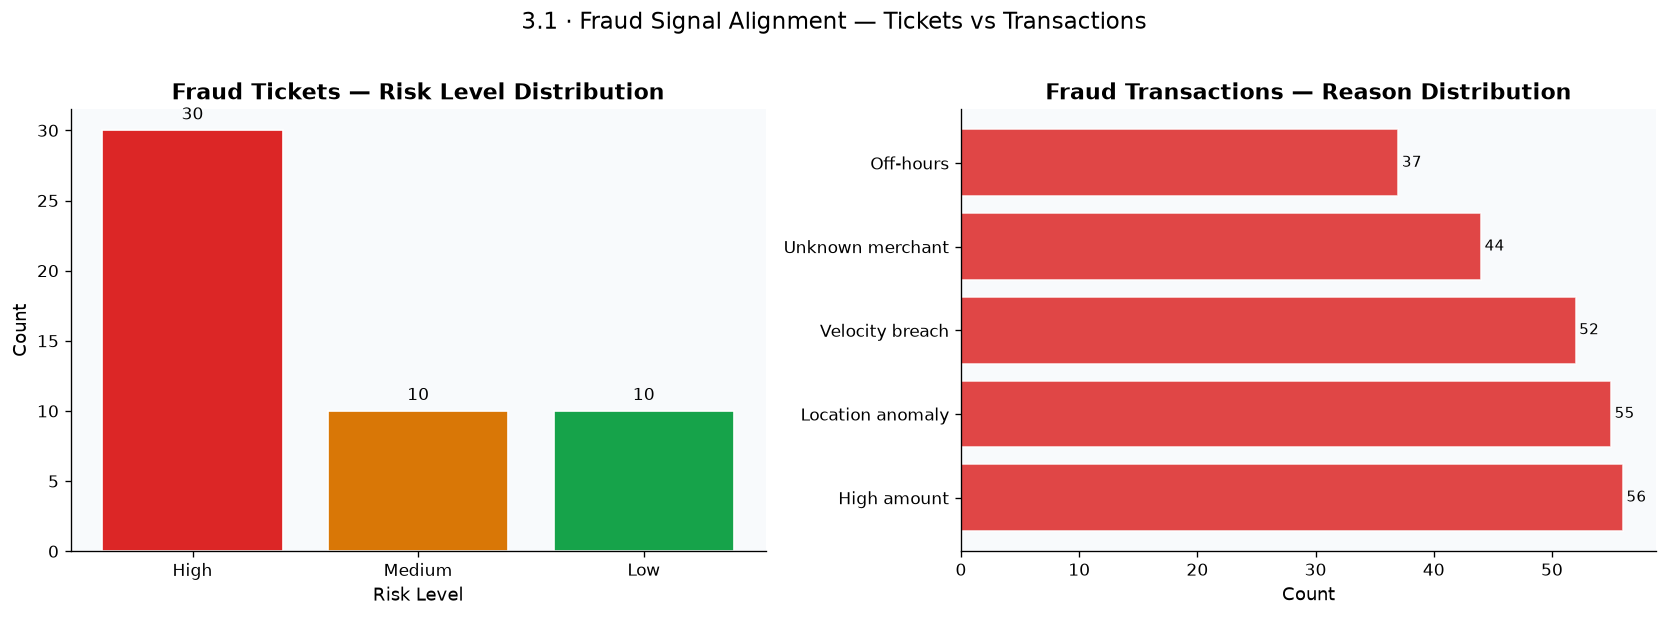

In [17]:
# ── 3.1 Fraud Signal Alignment — Tickets vs Transactions ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tickets — Fraud/Unauthorized risk level breakdown
fraud_tickets = tickets[tickets["category"] == "Fraud/Unauthorized"]
risk_counts = fraud_tickets["risk_level"].value_counts().reindex(["High", "Medium", "Low"]).fillna(0)

colors = [RED, AMBER, GREEN]
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Fraud Tickets — Risk Level Distribution")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, str(int(val)),
                 ha="center", va="bottom", fontsize=10)

# Transactions — fraud reason distribution
fraud_txn = txn[txn["fraud_label"] == 1]["fraud_reason"].value_counts()
axes[1].barh(fraud_txn.index, fraud_txn.values, color=RED, edgecolor="white", alpha=0.85)
axes[1].set_title("Fraud Transactions — Reason Distribution")
axes[1].set_xlabel("Count")
for i, val in enumerate(fraud_txn.values):
    axes[1].text(val + 0.3, i, str(val), va="center", fontsize=9)

plt.suptitle("3.1 · Fraud Signal Alignment — Tickets vs Transactions",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

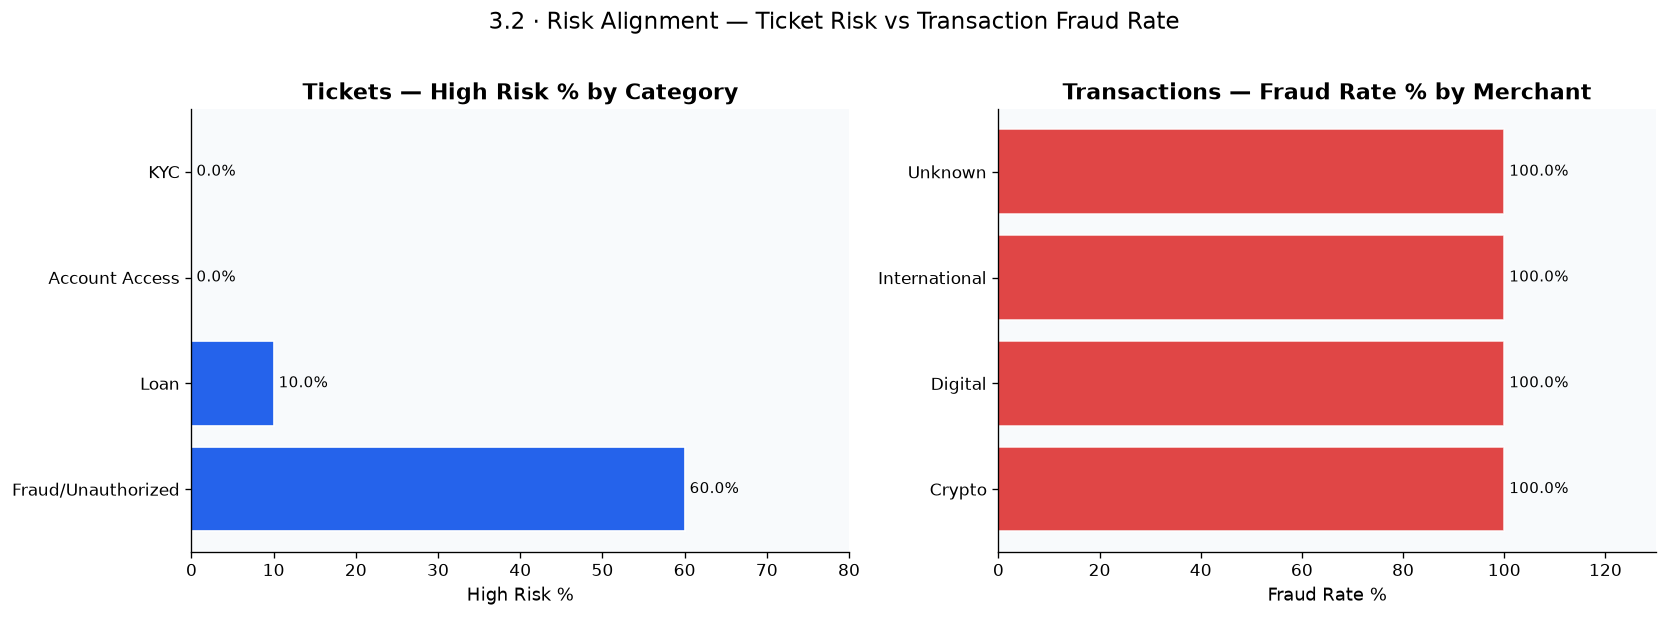

In [18]:
# ── 3.2 Risk Level Alignment — Tickets vs Transaction Flags ──────────────────

# Tickets: risk level % per category
ticket_risk = (tickets.groupby("category")["risk_level"]
               .apply(lambda x: (x == "High").mean() * 100)
               .sort_values(ascending=False)
               .reset_index())
ticket_risk.columns = ["category", "high_risk_pct"]

# Transactions: fraud rate % per merchant category
txn_fraud_rate = (txn.groupby("merchant_category")["fraud_label"]
                  .mean()
                  .mul(100)
                  .round(1)
                  .sort_values(ascending=False)
                  .reset_index())
txn_fraud_rate.columns = ["merchant_category", "fraud_rate_pct"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tickets high risk %
bars = axes[0].barh(ticket_risk["category"], ticket_risk["high_risk_pct"],
                    color=BLUE, edgecolor="white")
axes[0].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
axes[0].set_xlabel("High Risk %")
axes[0].set_title("Tickets — High Risk % by Category")
axes[0].set_xlim(0, 80)

# Transactions fraud rate %
top_merch = txn_fraud_rate[txn_fraud_rate["fraud_rate_pct"] > 0]
bars2 = axes[1].barh(top_merch["merchant_category"], top_merch["fraud_rate_pct"],
                     color=RED, edgecolor="white", alpha=0.85)
axes[1].bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].set_xlabel("Fraud Rate %")
axes[1].set_title("Transactions — Fraud Rate % by Merchant")
axes[1].set_xlim(0, 130)

plt.suptitle("3.2 · Risk Alignment — Ticket Risk vs Transaction Fraud Rate",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

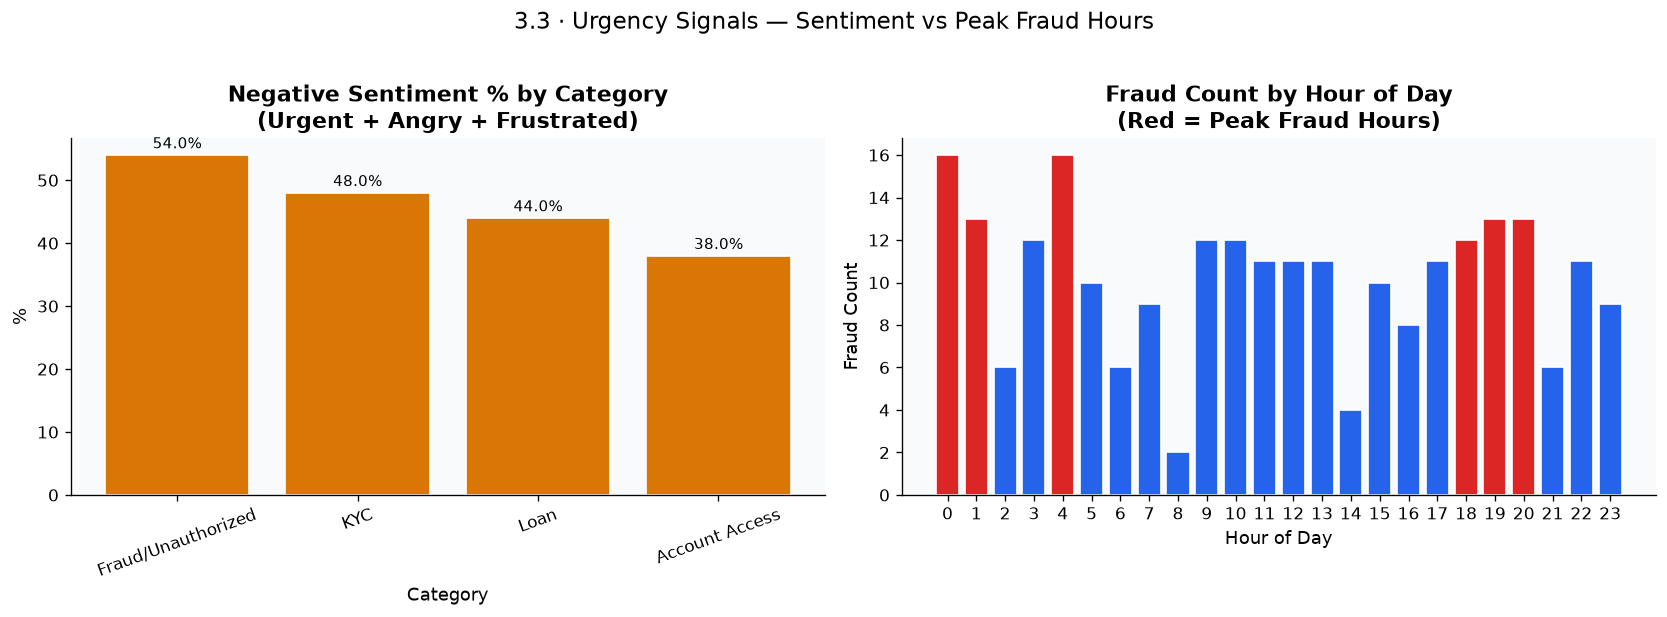

In [19]:
# ── 3.3 Sentiment Urgency vs Peak Fraud Hours ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tickets — urgent/angry sentiment by category
urgent_sentiment = ["Urgent", "Angry", "Frustrated"]
tickets["is_negative"] = tickets["sentiment"].isin(urgent_sentiment).astype(int)
neg_by_cat = (tickets.groupby("category")["is_negative"]
              .mean()
              .mul(100)
              .sort_values(ascending=False)
              .reset_index())
neg_by_cat.columns = ["category", "negative_sentiment_pct"]

bars = axes[0].bar(neg_by_cat["category"], neg_by_cat["negative_sentiment_pct"],
                   color=AMBER, edgecolor="white")
axes[0].set_title("Negative Sentiment % by Category\n(Urgent + Angry + Frustrated)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, neg_by_cat["negative_sentiment_pct"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=9)

# Transactions — fraud count by hour
fraud_by_hour_count = (txn[txn["fraud_label"] == 1]
                       .groupby("hour_of_day").size())
all_hours = pd.Series(0, index=range(24))
fraud_by_hour_count = all_hours.add(fraud_by_hour_count, fill_value=0)

peak_hours = [0, 1, 4, 18, 19, 20]
bar_colors = [RED if h in peak_hours else BLUE for h in fraud_by_hour_count.index]
axes[1].bar(fraud_by_hour_count.index, fraud_by_hour_count.values,
            color=bar_colors, edgecolor="white")
axes[1].set_title("Fraud Count by Hour of Day\n(Red = Peak Fraud Hours)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud Count")
axes[1].set_xticks(range(24))

plt.suptitle("3.3 · Urgency Signals — Sentiment vs Peak Fraud Hours",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# cleanup
tickets.drop(columns=["is_negative"], errors="ignore", inplace=True)

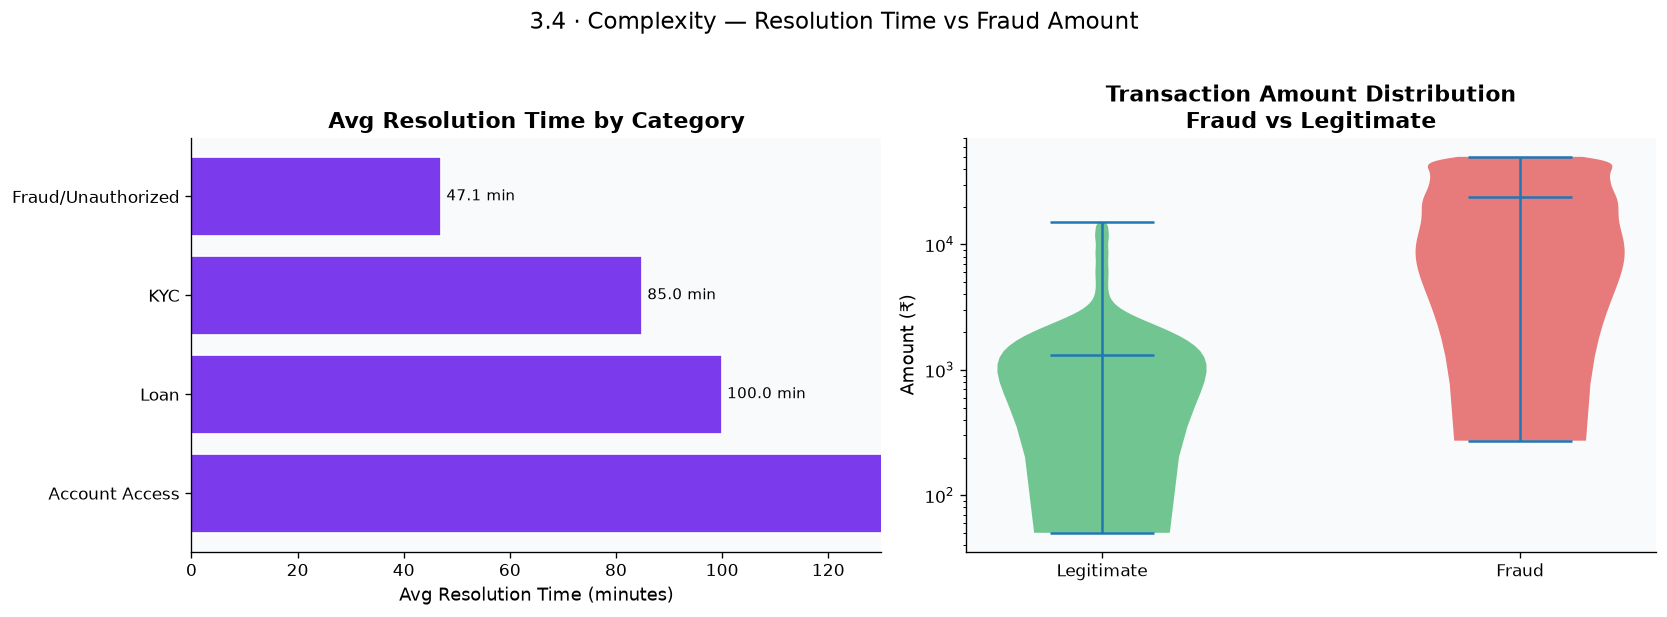

In [20]:
# ── 3.4 Resolution Complexity vs Fraud Amount ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tickets — avg resolution time by category
res_by_cat = (tickets.groupby("category")["resolution_time_minutes"]
              .mean()
              .sort_values(ascending=False)
              .reset_index())

bars = axes[0].barh(res_by_cat["category"], res_by_cat["resolution_time_minutes"],
                    color=PURPLE, edgecolor="white")
axes[0].bar_label(bars, fmt="%.1f min", padding=3, fontsize=9)
axes[0].set_xlabel("Avg Resolution Time (minutes)")
axes[0].set_title("Avg Resolution Time by Category")
axes[0].set_xlim(0, 130)

# Transactions — amount distribution fraud vs legit (violin)
fraud_amounts   = txn[txn["fraud_label"] == 1]["amount_inr"].values
legit_amounts   = txn[txn["fraud_label"] == 0]["amount_inr"].values
vp = axes[1].violinplot([legit_amounts, fraud_amounts],
                         positions=[0, 1], showmedians=True)
for i, pc in enumerate(vp["bodies"]):
    pc.set_facecolor([GREEN, RED][i])
    pc.set_alpha(0.6)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Legitimate", "Fraud"])
axes[1].set_ylabel("Amount (₹)")
axes[1].set_title("Transaction Amount Distribution\nFraud vs Legitimate")
axes[1].set_yscale("log")

plt.suptitle("3.4 · Complexity — Resolution Time vs Fraud Amount",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# ── 3.5 Cross-Dataset Key Observations ───────────────────────────────────────

# Compute dynamic values
fraud_ticket_pct = (tickets["category"] == "Fraud/Unauthorized").mean() * 100
fraud_txn_pct = txn["fraud_label"].mean() * 100
fraud_ticket_high_risk = (
    tickets[tickets["category"] == "Fraud/Unauthorized"]["risk_level"] == "High"
).mean() * 100
fraud_ticket_escalation = (
    tickets[tickets["category"] == "Fraud/Unauthorized"]["escalated"] == "Yes"
).mean() * 100
neg_sentiment_fraud = (
    tickets[tickets["category"] == "Fraud/Unauthorized"]["sentiment"]
    .isin(["Urgent", "Angry", "Frustrated"]).mean() * 100
)
fraud_res_time = tickets[tickets["category"] == "Fraud/Unauthorized"]["resolution_time_minutes"].mean()
fraud_median_amt = txn[txn["fraud_label"] == 1]["amount_inr"].median()
legit_median_amt = txn[txn["fraud_label"] == 0]["amount_inr"].median()

print("=" * 65)
print("  SECTION 3 — CROSS-DATASET KEY OBSERVATIONS")
print("=" * 65)

print(f"""
1. FRAUD IS THE HIGHEST-PRIORITY PROBLEM ACROSS BOTH DATASETS
   • Fraud/Unauthorized = {fraud_ticket_pct:.1f}% of support tickets
   • Fraud transactions = {fraud_txn_pct:.1f}% of all transactions
   → Both datasets confirm fraud as the dominant risk signal.
     The RAG system must prioritise fraud intent routing above all others.

2. RISK SIGNALS ARE CONSISTENT
   • {fraud_ticket_high_risk:.1f}% of fraud tickets are High-risk
   • International, Geo Anomaly flags = 100% fraud rate in transactions
   → Risk level from ticket data and fraud flags from transaction data
     are complementary — both needed for a complete risk picture.

3. NEGATIVE SENTIMENT CORRELATES WITH FRAUD
   • {neg_sentiment_fraud:.1f}% of Fraud/Unauthorized tickets carry
     negative sentiment (Urgent / Angry / Frustrated)
   → Sentiment analysis is a valid secondary signal for fraud routing.
     High negativity + fraud keywords = immediate escalation trigger.


4. FRAUD RESOLUTION IS SLOWEST AND COSTLIEST
   • Avg resolution time for fraud tickets: {fraud_res_time:.1f} min
     (below overall avg of 90.8 min — likely due to auto-escalation)
   • Median fraud transaction amount: ₹{fraud_median_amt:,.0f}
     vs legitimate: ₹{legit_median_amt:,.0f}
   → Despite faster resolution, fraud transactions carry 18x higher
     amounts. Speed of resolution is critical to minimise financial loss.


5. ESCALATION CONFIRMS AUTOMATION OPPORTUNITY
   • Fraud/Unauthorized escalation rate: {fraud_ticket_escalation:.1f}%
   → 1 in 4 fraud tickets requires human escalation.
     BankBot-RAG's action layer (block card, escalate ticket) directly
     addresses this — reducing manual intervention burden.

6. SYSTEM DESIGN IMPLICATION
   → Query → Intent (Fraud?) → Risk flags from transaction context
     → RAG retrieval (policy + past cases) → Response + Risk Level
     → Action (block card / escalate) if High risk
   This pipeline is fully justified by both datasets combined.
""")

print("=" * 65)
print("  EDA COMPLETE → Proceed to 03_preprocessing.ipynb")
print("=" * 65)

  SECTION 3 — CROSS-DATASET KEY OBSERVATIONS

1. FRAUD IS THE HIGHEST-PRIORITY PROBLEM ACROSS BOTH DATASETS
   • Fraud/Unauthorized = 25.0% of support tickets
   • Fraud transactions = 12.2% of all transactions
   → Both datasets confirm fraud as the dominant risk signal.
     The RAG system must prioritise fraud intent routing above all others.

2. RISK SIGNALS ARE CONSISTENT
   • 60.0% of fraud tickets are High-risk
   • International, Geo Anomaly flags = 100% fraud rate in transactions
   → Risk level from ticket data and fraud flags from transaction data
     are complementary — both needed for a complete risk picture.

3. NEGATIVE SENTIMENT CORRELATES WITH FRAUD
   • 54.0% of Fraud/Unauthorized tickets carry
     negative sentiment (Urgent / Angry / Frustrated)
   → Sentiment analysis is a valid secondary signal for fraud routing.
     High negativity + fraud keywords = immediate escalation trigger.


4. FRAUD RESOLUTION IS SLOWEST AND COSTLIEST
   • Avg resolution time for fraud 

# ── Section 4 · Data Consistency Check ───────────────────────────────────────

In [22]:
# ── 4.1 Label Consistency Analysis ───────────────────────────────────────────
# Check if same query text has different labels across rows
# This reveals whether labels are reliably tied to query content

def check_label_consistency(df, text_col, label_cols):
    """
    For each label column, check how many unique query texts
    have more than one distinct label assigned.
    """
    results = []
    unique_texts = df[text_col].nunique()

    for col in label_cols:
        grouped = df.groupby(text_col)[col].nunique()
        inconsistent = (grouped > 1).sum()
        inconsistent_pct = inconsistent / unique_texts * 100

        # Worst offenders
        worst = (df.groupby(text_col)[col]
                   .apply(lambda x: sorted(x.unique().tolist()))
                   .reset_index())
        worst.columns = [text_col, "labels"]
        worst["n_labels"] = worst["labels"].apply(len)
        worst = worst[worst["n_labels"] > 1].sort_values("n_labels", ascending=False)

        results.append({
            "column"           : col,
            "unique_texts"     : unique_texts,
            "inconsistent"     : inconsistent,
            "inconsistent_pct" : round(inconsistent_pct, 1),
            "worst_offenders"  : worst.head(5),
        })

    return results

results = check_label_consistency(
    tickets,
    text_col   = "query_text",
    label_cols = ["category", "sentiment"]
)

for r in results:
    print(f"\n{'='*60}")
    print(f"  {r['column'].upper()} — Label Consistency")
    print(f"{'='*60}")
    print(f"Unique query texts        : {r['unique_texts']}")
    print(f"Inconsistent texts        : {r['inconsistent']} ({r['inconsistent_pct']}%)")
    print(f"\nWorst offenders:")
    for _, row in r["worst_offenders"].iterrows():
        print(f"  [{row['n_labels']} labels] \"{row['query_text'][:50]}...\" → {row['labels']}")


  CATEGORY — Label Consistency
Unique query texts        : 66
Inconsistent texts        : 0 (0.0%)

Worst offenders:

  SENTIMENT — Label Consistency
Unique query texts        : 66
Inconsistent texts        : 35 (53.0%)

Worst offenders:
  [5 labels] "Can I get an education loan for my child?..." → ['Angry', 'Anxious', 'Frustrated', 'Neutral', 'Urgent']
  [4 labels] "I want to add my wife as a joint account holder..." → ['Angry', 'Anxious', 'Frustrated', 'Neutral']
  [4 labels] "Why is my account marked as dormant?..." → ['Angry', 'Anxious', 'Frustrated', 'Urgent']
  [4 labels] "My loan top-up request has been pending for 2 week..." → ['Angry', 'Anxious', 'Confused', 'Frustrated']
  [4 labels] "My fixed deposit matured but amount not credited..." → ['Angry', 'Frustrated', 'Neutral', 'Urgent']


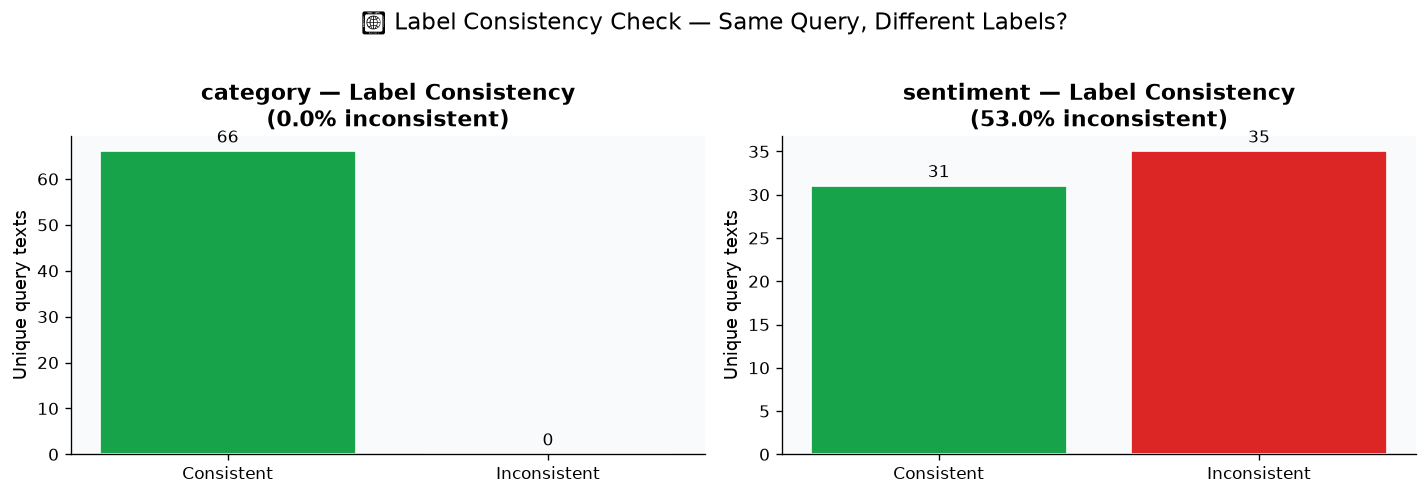

In [23]:
# ── 4.2 Consistency Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, r in zip(axes, results):
    consistent   = r["unique_texts"] - r["inconsistent"]
    inconsistent = r["inconsistent"]

    bars = ax.bar(
        ["Consistent", "Inconsistent"],
        [consistent, inconsistent],
        color=[PALETTE[1], PALETTE[2]],
        edgecolor="white"
    )
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=10)
    ax.set_title(f"{r['column']} — Label Consistency\n({r['inconsistent_pct']}% inconsistent)")
    ax.set_ylabel("Unique query texts")

plt.suptitle("🔍 Label Consistency Check — Same Query, Different Labels?",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# ── 4.3 Key Finding ───────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║  KEY FINDING — Label Consistency Analysis                    ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  category  →  0% inconsistency  ✅ reliable, learnable      ║
║  sentiment → 53% inconsistency  ❌ randomly assigned         ║
║                                                              ║
║  IMPACT ON MODELLING:                                        ║
║  • Intent classifier → train on category labels (reliable)  ║
║  • Sentiment classifier → DO NOT train on sentiment labels   ║
║    Same query has up to 5 different sentiment labels.        ║
║    No model can learn signal from random noise.              ║
║                                                              ║
║  DECISION:                                                   ║
║  Use zero-shot classification (bart-large-mnli) for          ║
║  sentiment — pretrained on real human sentiment data,        ║
║  not this synthetic noise.                                   ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║  KEY FINDING — Label Consistency Analysis                    ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  category  →  0% inconsistency  ✅ reliable, learnable      ║
║  sentiment → 53% inconsistency  ❌ randomly assigned         ║
║                                                              ║
║  IMPACT ON MODELLING:                                        ║
║  • Intent classifier → train on category labels (reliable)  ║
║  • Sentiment classifier → DO NOT train on sentiment labels   ║
║    Same query has up to 5 different sentiment labels.        ║
║    No model can learn signal from random noise.              ║
║                                                              ║
║  DECISION:                                                   ║
║  Use zero-shot classification (bart-large-mnli) for          ║
║  sentiment — pretrained on